In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/keva/Downloads/digital_payment_behavior_clustering_dataset.csv')
df.head()

,user_id,city,device_type,kyc_level,account_age_months,account_age_band,active_days_per_month,transactions_per_day,monthly_transaction_count,avg_transaction_amount,...,night_txn_ratio,weekend_txn_ratio,session_count,app_open_frequency,avg_session_duration_min,avg_gap_between_txn_hours,spend_volatility,avg_balance_before_txn,cashback_usage_ratio,suspicious_activity_score
0,UPI00001,Mumbai,Android,Minimum,28,2y+,17,5.12,109,246.96,...,0.073,0.321,66,111,2.14,3.72,0.359,5464.53,0.333,26.91
1,UPI00002,Chennai,Android,Premium,11,6-12m,14,1.55,20,517.36,...,0.113,0.292,33,50,4.18,31.47,0.476,2894.69,0.327,13.03
2,UPI00003,Pune,Android,Premium,31,2y+,17,3.96,54,894.50,...,0.102,0.365,31,41,6.20,12.27,0.409,7560.72,0.279,32.01
3,UPI00004,Chennai,Android,Minimum,14,1-2y,11,9.99,110,1358.09,...,0.614,0.598,41,117,9.17,4.02,0.535,47098.46,0.373,77.72
4,UPI00005,Ahmedabad,Android,Full,29,2y+,16,11.99,167,493.71,...,0.553,0.448,44,84,7.42,3.23,0.847,55402.11,0.310,78.22


In [4]:
# Q1. How many unique users are present in the dataset?
df['user_id'].nunique()

5000

In [6]:
# Q2. Are there any missing values or duplicate records?
print("Missing values per column:")
print(df.isnull().sum().sum())
print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values per column:
0

Duplicate rows:
0


In [7]:
#Q3. Is each user_id unique
df['user_id'].nunique() == len(df)

True

In [9]:
#Q4. How many users belong to each city?
df['city'].value_counts()

city
Pune         643
Hyderabad    636
Delhi        632
Bengaluru    632
Mumbai       627
Ahmedabad    621
Chennai      606
Kolkata      603
Name: count, dtype: int64

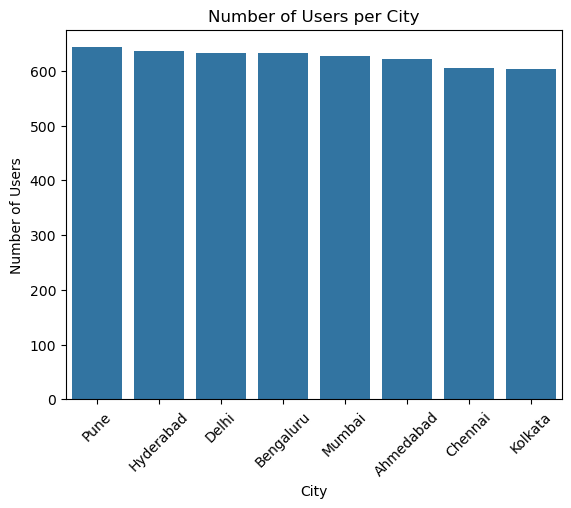

In [50]:
sns.countplot(data=df, x='city', order=df['city'].value_counts().index)
plt.title('Number of Users per City')
plt.xlabel('City')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.show()

In [11]:
#Q5. What is the distribution of users across Android and iOS devices?
df['device_type'].value_counts()

device_type
Android    3871
iOS        1129
Name: count, dtype: int64

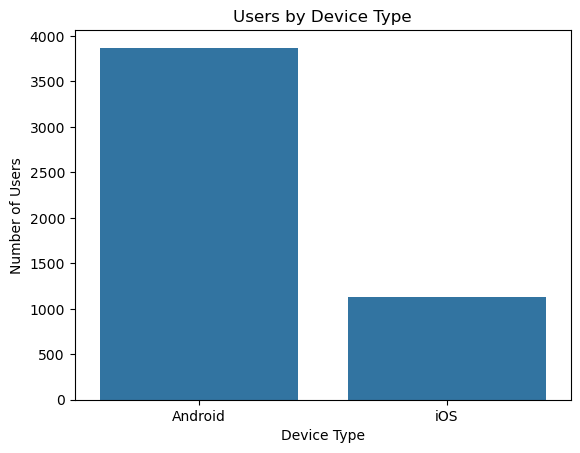

In [51]:
sns.countplot(data=df, x='device_type')
plt.title('Users by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Number of Users')
plt.show()

In [13]:
#Q6. How many users have Minimum, Full and Premium KYC levels?
df['kyc_level'].value_counts()

kyc_level
Full       2879
Minimum    1423
Premium     698
Name: count, dtype: int64

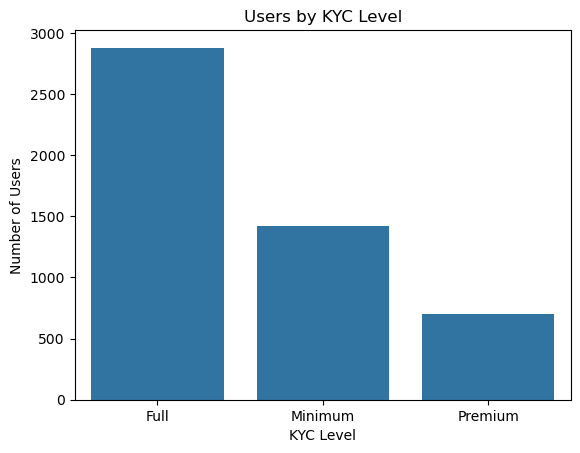

In [52]:
sns.countplot(data=df, x='kyc_level', order=df['kyc_level'].value_counts().index)
plt.title('Users by KYC Level')
plt.xlabel('KYC Level')
plt.ylabel('Number of Users')
plt.show()

In [15]:
#Q7. What is the distribution of users across the different account-age bands?
df['account_age_band'].value_counts()

account_age_band
1-2y     2241
2y+      1201
6-12m     882
0-6m      676
Name: count, dtype: int64

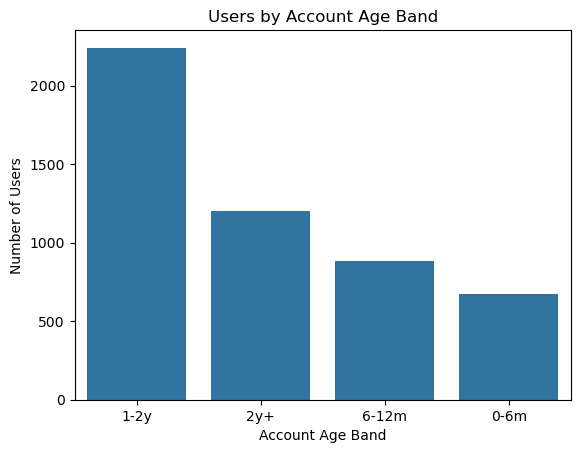

In [53]:
sns.countplot(data=df, x='account_age_band', order=df['account_age_band'].value_counts().index)
plt.title('Users by Account Age Band')
plt.xlabel('Account Age Band')
plt.ylabel('Number of Users')
plt.show()

In [17]:
#Q8. What are the minimum, maximum and average values of account_age_months?
df['account_age_months'].agg(['min', 'max', 'mean'])

min      1.000
max     58.000
mean    17.557
Name: account_age_months, dtype: float64

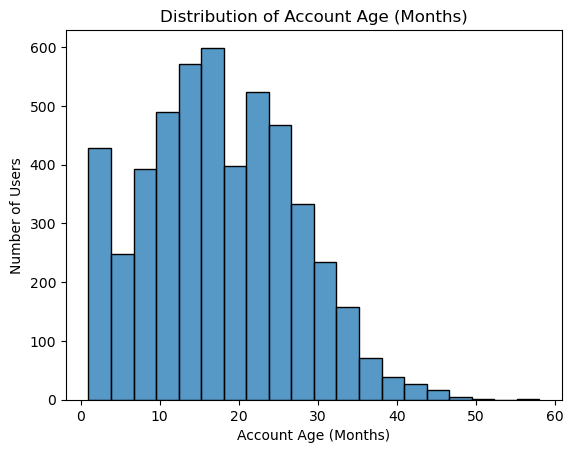

In [54]:
sns.histplot(data=df, x='account_age_months', bins=20)
plt.title('Distribution of Account Age (Months)')
plt.xlabel('Account Age (Months)')
plt.ylabel('Number of Users')
plt.show()

In [19]:
#Q9. Does account_age_band correctly correspond to account_age_months?
df.groupby('account_age_band')['account_age_months'].agg(['min', 'max', 'mean'])

,min,max,mean
account_age_band,,,
0-6m,1,6,2.789941
1-2y,13,24,18.319500
2y+,25,58,30.213988
6-12m,7,12,9.702948


In [31]:
#Q10. How do transaction activity and spending differ across KYC levels?
kyc = df.groupby("kyc_level")[["monthly_transaction_count","total_monthly_spend"]].mean()
print(kyc)


           monthly_transaction_count  total_monthly_spend
kyc_level                                                
Full                       86.377562         71639.020646
Minimum                    86.205903         67172.370562
Premium                    86.597421         68481.068095


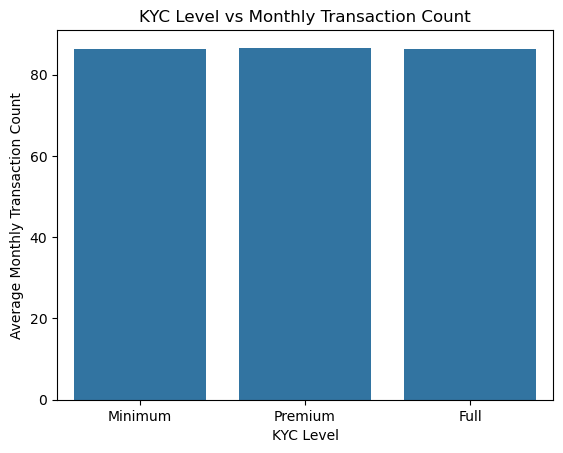

In [32]:
sns.barplot(x=df["kyc_level"], y=df["monthly_transaction_count"], errorbar=None)
plt.title("KYC Level vs Monthly Transaction Count")
plt.xlabel("KYC Level")
plt.ylabel("Average Monthly Transaction Count")
plt.show()

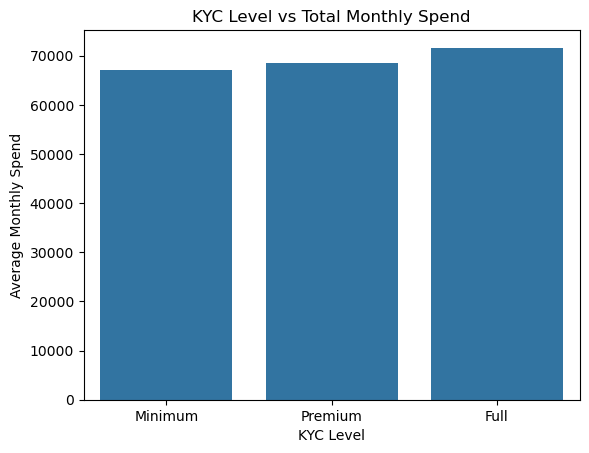

In [33]:
sns.barplot(x=df["kyc_level"], y=df["total_monthly_spend"], errorbar=None)
plt.title("KYC Level vs Total Monthly Spend")
plt.xlabel("KYC Level")
plt.ylabel("Average Monthly Spend")
plt.show()

In [22]:
#Q11. What is the average number of active days per month?
df['active_days_per_month'].mean()

np.float64(17.1322)

In [23]:
#Q12. What is the distribution of monthly_transaction_count?
df['monthly_transaction_count'].describe()

count    5000.000000
mean       86.359400
std        68.038231
min         1.000000
25%        32.000000
50%        75.000000
75%       127.000000
max       440.000000
Name: monthly_transaction_count, dtype: float64

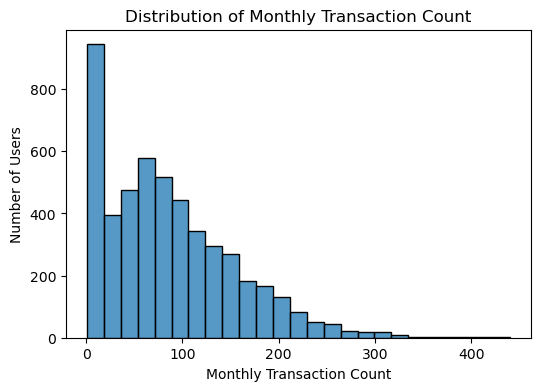

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='monthly_transaction_count', bins=25)
plt.title('Distribution of Monthly Transaction Count')
plt.xlabel('Monthly Transaction Count')
plt.ylabel('Number of Users')
plt.show()

In [25]:
#Q13. Which users complete the highest number of monthly transactions?
df.sort_values(by='monthly_transaction_count', ascending=False).head(10)[['user_id', 'monthly_transaction_count']]

,user_id,monthly_transaction_count
2656,UPI02657,440
3394,UPI03395,411
2099,UPI02100,403
4907,UPI04908,401
3350,UPI03351,385
1516,UPI01517,364
289,UPI00290,363
1654,UPI01655,343
2083,UPI02084,343
1557,UPI01558,341


In [26]:
#Q14. Which users have the highest transactions_per_day?
df.sort_values(by='transactions_per_day', ascending=False).head(10)[['user_id', 'transactions_per_day']]

,user_id,transactions_per_day
273,UPI00274,20.11
4237,UPI04238,19.78
278,UPI00279,19.65
3394,UPI03395,19.18
3725,UPI03726,19.11
2656,UPI02657,19.00
663,UPI00664,18.69
1889,UPI01890,18.31
2954,UPI02955,18.07
685,UPI00686,18.00


In [27]:
#Q15. How is active_days_per_month related to monthly_transaction_count?
print("Correlation:", df['active_days_per_month'].corr(df['monthly_transaction_count']))

Correlation: 0.7022107105795311


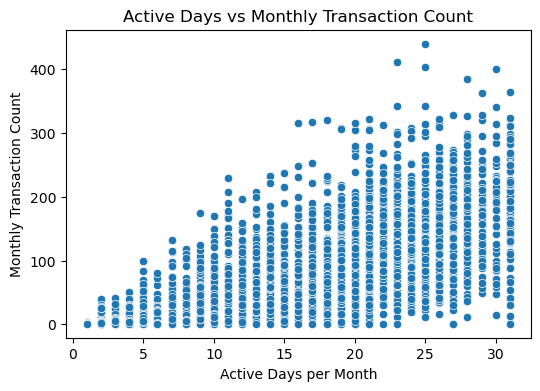

In [28]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='active_days_per_month', y='monthly_transaction_count')
plt.title('Active Days vs Monthly Transaction Count')
plt.xlabel('Active Days per Month')
plt.ylabel('Monthly Transaction Count')
plt.show()

In [34]:
#Q16. Which users perform many transactions within relatively few active days?
result = df.sort_values(by="transactions_per_day", ascending=False)

print(result[["user_id",
              "active_days_per_month",
              "monthly_transaction_count",
              "transactions_per_day"]].head(10))

       user_id  active_days_per_month  monthly_transaction_count  \
273   UPI00274                      2                         39   
4237  UPI04238                      5                        100   
278   UPI00279                      9                        175   
3394  UPI03395                     23                        411   
3725  UPI03726                     11                        230   
2656  UPI02657                     25                        440   
663   UPI00664                     11                        208   
1889  UPI01890                     18                        321   
2954  UPI02955                     17                        318   
685   UPI00686                     16                        315   

      transactions_per_day  
273                  20.11  
4237                 19.78  
278                  19.65  
3394                 19.18  
3725                 19.11  
2656                 19.00  
663                  18.69  
1889               

In [35]:
#Q17. Which users are active frequently but complete relatively few transactions?
result = df.sort_values(by=["active_days_per_month",
                            "monthly_transaction_count"],
                        ascending=[False, True])

print(result[["user_id",
              "active_days_per_month",
              "monthly_transaction_count"]].head(10))

       user_id  active_days_per_month  monthly_transaction_count
421   UPI00422                     31                          1
400   UPI00401                     31                          2
3002  UPI03003                     31                         13
4451  UPI04452                     31                         31
943   UPI00944                     31                         40
1880  UPI01881                     31                         41
644   UPI00645                     31                         54
3336  UPI03337                     31                         66
1141  UPI01142                     31                         73
1863  UPI01864                     31                         88


account_age_band
0-6m     35.801627
1-2y     38.799241
2y+      34.940325
6-12m    41.961701
Name: avg_gap_between_txn_hours, dtype: float64


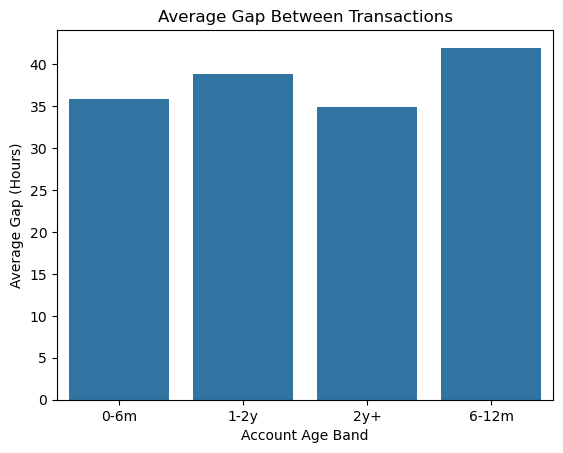

In [36]:
#Q18. What is the average gap between transactions for different levels of transaction activity?
activity = df.groupby("account_age_band")["avg_gap_between_txn_hours"].mean()

print(activity)

sns.barplot(x=activity.index,
            y=activity.values,
            errorbar=None)

plt.title("Average Gap Between Transactions")
plt.xlabel("Account Age Band")
plt.ylabel("Average Gap (Hours)")
plt.show()

In [37]:
#19.Which users have unusually short gaps between consecutive transactions?
gap = df.sort_values(by="avg_gap_between_txn_hours")

print(gap[["user_id","avg_gap_between_txn_hours"]].head(10))

       user_id  avg_gap_between_txn_hours
1289  UPI01290                        0.2
4975  UPI04976                        0.2
1050  UPI01051                        0.2
3377  UPI03378                        0.2
4176  UPI04177                        0.2
4595  UPI04596                        0.2
3350  UPI03351                        0.2
2769  UPI02770                        0.2
1056  UPI01057                        0.2
1387  UPI01388                        0.2


account_age_band
0-6m     89.343195
1-2y     86.827309
2y+      86.867610
6-12m    82.191610
Name: monthly_transaction_count, dtype: float64


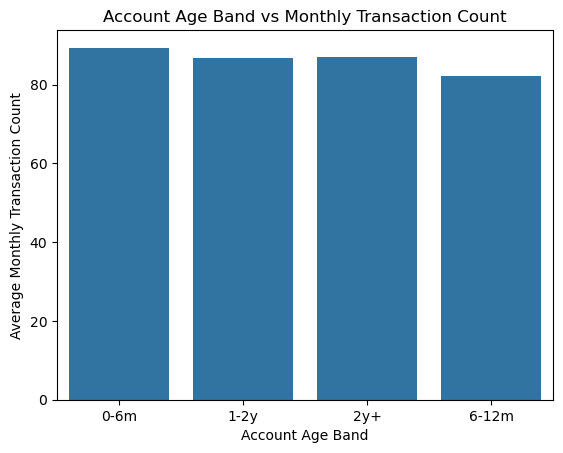

In [38]:
#20.How does transaction activity differ across account-age bands?
activity = df.groupby("account_age_band")["monthly_transaction_count"].mean()

print(activity)

sns.barplot(x=activity.index,
            y=activity.values,
            errorbar=None)

plt.title("Account Age Band vs Monthly Transaction Count")
plt.xlabel("Account Age Band")
plt.ylabel("Average Monthly Transaction Count")
plt.show()

In [39]:
#21.
print("Average :", df["avg_transaction_amount"].mean())
print("Minimum :", df["avg_transaction_amount"].min())
print("Maximum :", df["avg_transaction_amount"].max())

Average : 953.655104
Minimum : 20.0
Maximum : 7057.3


In [40]:
#22.

highest_amount = df.sort_values(by="max_transaction_amount", ascending=False)
print(highest_amount[["user_id","max_transaction_amount"]].head(10))

       user_id  max_transaction_amount
2201  UPI02202                22554.74
4024  UPI04025                20400.60
4294  UPI04295                20174.47
708   UPI00709                20105.95
2811  UPI02812                20080.83
4579  UPI04580                19161.80
1972  UPI01973                18589.06
2129  UPI02130                18220.86
1430  UPI01431                18019.58
3809  UPI03810                17707.12


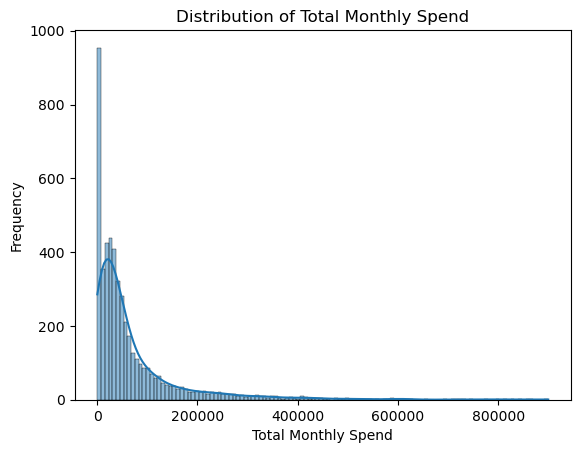

In [41]:
#23. What is the distribution of total_monthly_spend?
sns.histplot(x=df["total_monthly_spend"], kde=True)
plt.title("Distribution of Total Monthly Spend")
plt.xlabel("Total Monthly Spend")
plt.ylabel("Frequency")
plt.show()

In [42]:
#24.Which users have the highest total monthly spending?

highest_spend = df.sort_values(by="total_monthly_spend", ascending=False)
print(highest_spend[["user_id","total_monthly_spend"]].head(10))

       user_id  total_monthly_spend
2099  UPI02100            900000.00
3758  UPI03759            900000.00
4907  UPI04908            900000.00
2037  UPI02038            868849.19
685   UPI00686            859324.54
1981  UPI01982            844171.60
289   UPI00290            832306.30
2036  UPI02037            815972.77
1137  UPI01138            812219.61
130   UPI00131            800263.43


Correlation: 0.3071817633591186


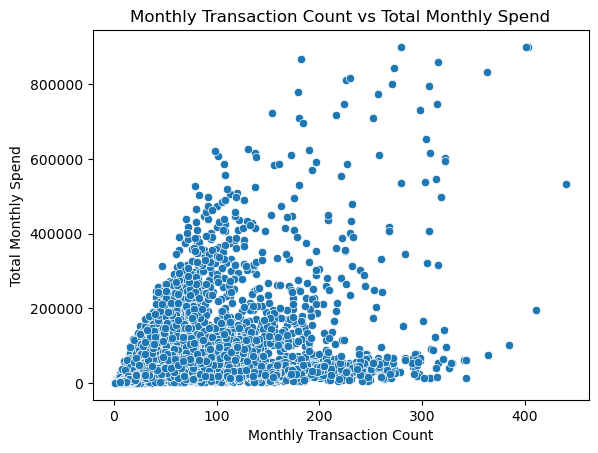

In [43]:
#25. How is monthly_transaction_count related to total_monthly_spend?

print("Correlation:", df['monthly_transaction_count'].corr(df['total_monthly_spend']))
sns.scatterplot(x=df["monthly_transaction_count"],
                y=df["total_monthly_spend"])

plt.title("Monthly Transaction Count vs Total Monthly Spend")
plt.xlabel("Monthly Transaction Count")
plt.ylabel("Total Monthly Spend")

plt.show()

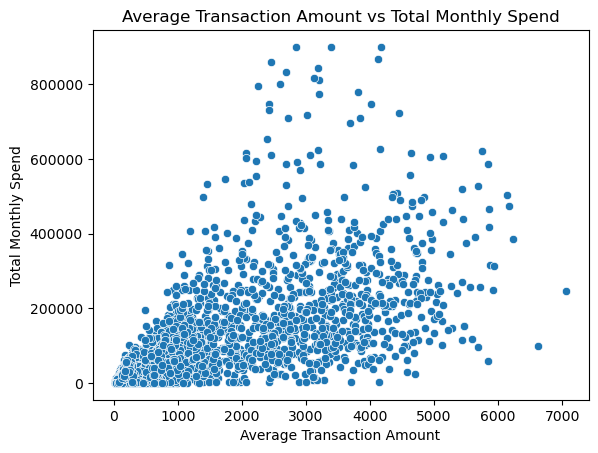

In [44]:
#26.How is avg_transaction_amount related to total_monthly_spend?

sns.scatterplot(x=df["avg_transaction_amount"],
                y=df["total_monthly_spend"])

plt.title("Average Transaction Amount vs Total Monthly Spend")
plt.xlabel("Average Transaction Amount")
plt.ylabel("Total Monthly Spend")

plt.show()

In [45]:
#27.Which users make frequent transactions with relatively small transaction amounts?

result = df.sort_values(by=["monthly_transaction_count",
                            "avg_transaction_amount"],
                        ascending=[False, True])

print(result[["user_id",
              "monthly_transaction_count",
              "avg_transaction_amount"]].head(10))

       user_id  monthly_transaction_count  avg_transaction_amount
2656  UPI02657                        440                 1462.45
3394  UPI03395                        411                  485.10
2099  UPI02100                        403                 4166.72
4907  UPI04908                        401                 3396.53
3350  UPI03351                        385                  244.73
1516  UPI01517                        364                  177.51
289   UPI00290                        363                 2692.39
2083  UPI02084                        343                   40.00
1654  UPI01655                        343                  154.30
1557  UPI01558                        341                  174.29


In [46]:
#28.Which users make fewer transactions but have high average transaction amounts?
result = df.sort_values(by=["monthly_transaction_count",
                            "avg_transaction_amount"],
                        ascending=[True, False])

print(result[["user_id",
              "monthly_transaction_count",
              "avg_transaction_amount"]].head(10))

       user_id  monthly_transaction_count  avg_transaction_amount
4916  UPI04917                          1                 4133.28
2758  UPI02759                          1                 3699.61
2486  UPI02487                          1                 2999.04
359   UPI00360                          1                 2893.08
642   UPI00643                          1                 2427.31
4291  UPI04292                          1                 2057.23
256   UPI00257                          1                 1971.51
1591  UPI01592                          1                 1905.09
4634  UPI04635                          1                 1859.54
3301  UPI03302                          1                 1800.47


In [47]:
#29.Which users have a large difference between their average and maximum transaction amounts?

df["Amount_Difference"] = df["max_transaction_amount"] - df["avg_transaction_amount"]
result = df.sort_values(by="Amount_Difference", ascending=False)
print(result[["user_id",
              "avg_transaction_amount",
              "max_transaction_amount",
              "Amount_Difference"]].head(10))

       user_id  avg_transaction_amount  max_transaction_amount  \
2201  UPI02202                 5129.47                22554.74   
4294  UPI04295                 4707.99                20174.47   
708   UPI00709                 4950.02                20105.95   
2811  UPI02812                 5434.26                20080.83   
4024  UPI04025                 5923.59                20400.60   
4579  UPI04580                 4795.15                19161.80   
2129  UPI02130                 4696.62                18220.86   
2747  UPI02748                 3840.05                17320.02   
1019  UPI01020                 4293.44                17552.53   
1430  UPI01431                 5133.52                18019.58   

      Amount_Difference  
2201           17425.27  
4294           15466.48  
708            15155.93  
2811           14646.57  
4024           14477.01  
4579           14366.65  
2129           13524.24  
2747           13479.97  
1019           13259.09  
1430         

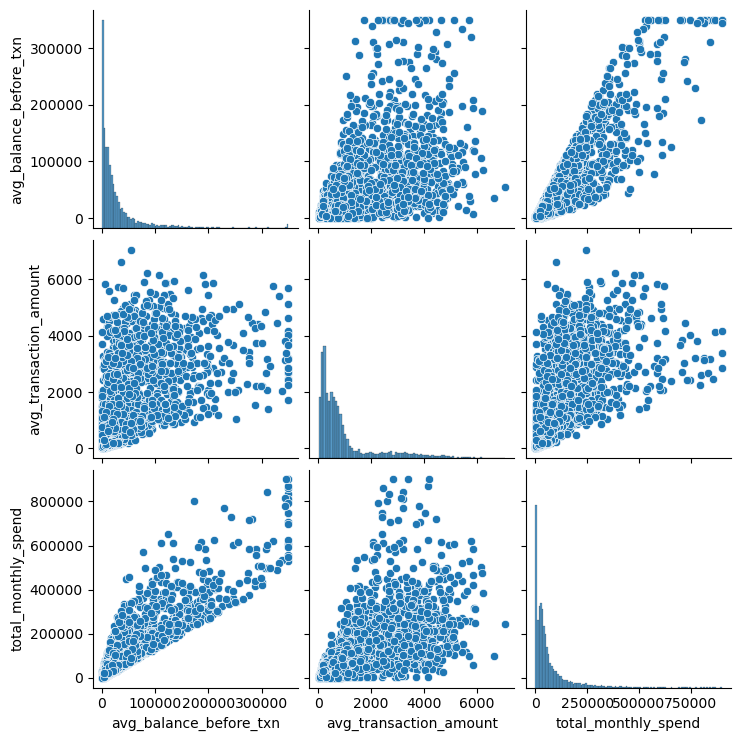

In [49]:
#30.How is avg_balance_before_txn related to average transaction amount and total monthly spending?

sns.pairplot(df[["avg_balance_before_txn","avg_transaction_amount",  "total_monthly_spend"]])
plt.show()

In [55]:
#31.What proportion of transactions is made with merchants?
df["merchant_txn_ratio"].describe()

count    5000.000000
mean        0.618921
std         0.167068
min         0.200000
25%         0.507000
50%         0.608000
75%         0.715000
max         0.959000
Name: merchant_txn_ratio, dtype: float64

In [56]:
#32. What proportion of transactions consists of peer-to-peer transfers?
df["peer_txn_ratio"].describe()

count    5000.000000
mean        0.381818
std         0.171862
min         0.020000
25%         0.270000
50%         0.390000
75%         0.492000
max         0.850000
Name: peer_txn_ratio, dtype: float64

In [57]:
#33. Which users are primarily merchant-transaction users?
result = df.sort_values(by="merchant_txn_ratio", ascending=False)
print(result[["user_id","merchant_txn_ratio"]].head(10))

       user_id  merchant_txn_ratio
1068  UPI01069               0.959
666   UPI00667               0.959
1858  UPI01859               0.958
4239  UPI04240               0.958
1967  UPI01968               0.958
729   UPI00730               0.958
1854  UPI01855               0.958
2796  UPI02797               0.958
4622  UPI04623               0.958
1709  UPI01710               0.958


In [58]:
#34.Which users are primarily peer-to-peer transaction users?
result = df.sort_values(by="peer_txn_ratio", ascending=False)
print(result[["user_id","peer_txn_ratio"]].head(10))

       user_id  peer_txn_ratio
2997  UPI02998            0.85
2599  UPI02600            0.85
1183  UPI01184            0.85
2360  UPI02361            0.85
2257  UPI02258            0.85
1056  UPI01057            0.85
33    UPI00034            0.85
863   UPI00864            0.85
1849  UPI01850            0.85
2734  UPI02735            0.85


In [59]:
#35. Which users have a balanced combination of merchant and peer transactions?
df["Ratio_Difference"] = abs(df["merchant_txn_ratio"] - df["peer_txn_ratio"])

result = df.sort_values(by="Ratio_Difference")

print(result[["user_id","merchant_txn_ratio","peer_txn_ratio"]].head(10))

       user_id  merchant_txn_ratio  peer_txn_ratio
2055  UPI02056               0.482           0.482
395   UPI00396               0.540           0.540
776   UPI00777               0.504           0.504
3232  UPI03233               0.520           0.520
4185  UPI04186               0.500           0.500
1503  UPI01504               0.461           0.462
2760  UPI02761               0.511           0.510
2643  UPI02644               0.504           0.505
4199  UPI04200               0.475           0.476
563   UPI00564               0.518           0.519


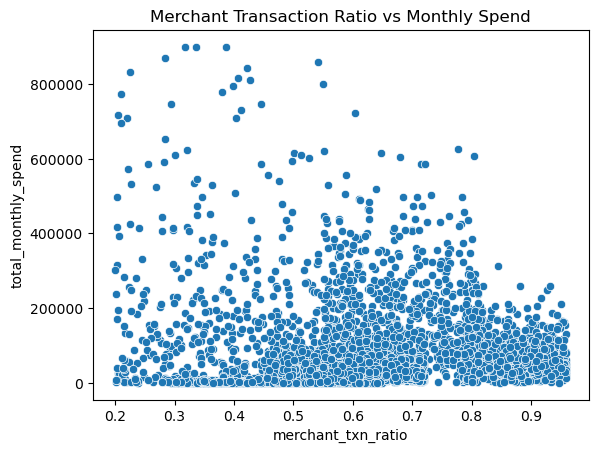

In [60]:
#36.How does total monthly spending differ between merchant-focused and peer-focused users?
sns.scatterplot(x=df["merchant_txn_ratio"], y=df["total_monthly_spend"])
plt.title("Merchant Transaction Ratio vs Monthly Spend")
plt.show()

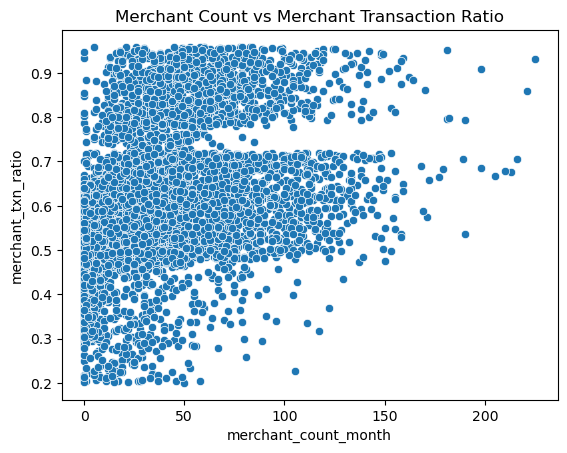

In [61]:
#37.How is merchant_count_month related to merchant_txn_ratio?

sns.scatterplot(x=df["merchant_count_month"], y=df["merchant_txn_ratio"])
plt.title("Merchant Count vs Merchant Transaction Ratio")
plt.show()

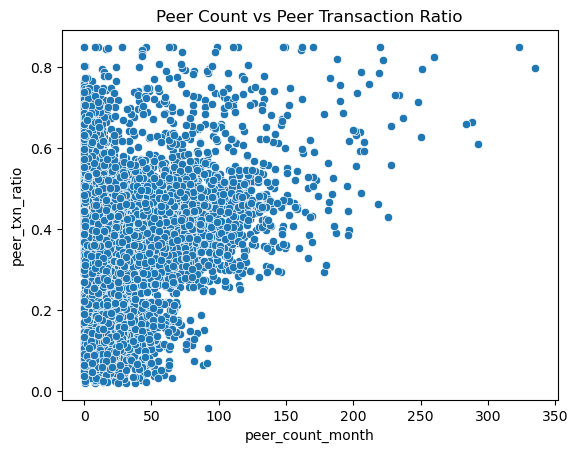

In [62]:
#38.How is peer_count_month related to peer_txn_ratio?

sns.scatterplot(x=df["peer_count_month"], y=df["peer_txn_ratio"])
plt.title("Peer Count vs Peer Transaction Ratio")
plt.show()

In [67]:
#39.Which users have the highest number of failed transactions?

result = df.sort_values(by="failed_transactions", ascending=False)
print(result[["user_id","failed_transactions"]].head(10))

       user_id  failed_transactions
3627  UPI03628                   39
3849  UPI03850                   37
2108  UPI02109                   36
898   UPI00899                   35
4230  UPI04231                   35
3936  UPI03937                   34
4466  UPI04467                   34
2294  UPI02295                   34
1025  UPI01026                   34
4327  UPI04328                   33


In [66]:
#40.Which users have the highest failed_txn_ratio?

result = df.sort_values(by="failed_txn_ratio", ascending=False)
print(result[["user_id","failed_txn_ratio"]].head(10))

       user_id  failed_txn_ratio
4999  UPI05000              0.35
1112  UPI01113              0.35
3985  UPI03986              0.35
1162  UPI01163              0.35
1165  UPI01166              0.35
1166  UPI01167              0.35
3971  UPI03972              0.35
1176  UPI01177              0.35
3967  UPI03968              0.35
1184  UPI01185              0.35


In [ ]:
#Q41. Which users have the highest number of refund requests?
sns.barplot(x=df["kyc_level"], y=df["failed_txn_ratio"], errorbar=None)

plt.title("KYC Level vs Failed Transaction Ratio")
plt.xlabel("KYC Level")
plt.ylabel("Failed Transaction Ratio")
plt.show()

In [ ]:
#Q42. How is refund_ratio related to failed_txn_ratio?
sns.scatterplot(x=df["failed_transactions"],
                y=df["suspicious_activity_score"])

plt.title("Failed Transactions vs Suspicious Activity Score")
plt.xlabel("Failed Transactions")
plt.ylabel("Suspicious Activity Score")
plt.show()

In [ ]:
#Q43. Do users with high failed-transaction ratios also show higher spending volatility?
result = df.sort_values(by="refund_requests", ascending=False)

print(result[["user_id","refund_requests"]].head(10))

In [ ]:
#Q44. Which users have unusually high suspicious_activity_score values?
sns.histplot(x=df["refund_ratio"], kde=True)

plt.title("Distribution of Refund Ratio")
plt.xlabel("Refund Ratio")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#Q45. How is suspicious activity related to night-time transactions, failed transactions and refunds?
result = df.sort_values(by="refund_ratio", ascending=False)

print(result[["user_id","refund_ratio"]].head(10))

In [ ]:
#Q46. Which users conduct a high proportion of their transactions at night or on weekends?
sns.scatterplot(x=df["refund_requests"],
                y=df["refund_ratio"])

plt.title("Refund Requests vs Refund Ratio")
plt.xlabel("Refund Requests")
plt.ylabel("Refund Ratio")
plt.show()

In [ ]:
#Q47. How are session_count and app_open_frequency related?
sns.barplot(x=df["account_age_band"],
            y=df["refund_requests"],
            errorbar=None)

plt.title("Account Age Band vs Refund Requests")
plt.xlabel("Account Age Band")
plt.ylabel("Refund Requests")
plt.show()

In [ ]:
#Q48. Which users open the application frequently but complete relatively few transactions?

In [ ]:
#Q49. How does cashback usage relate to merchant transactions, transaction frequency and monthly spending?


In [ ]:
#Q50. Which users show unusual behaviour based on transaction frequency, spending, timing, failures, refunds, app engagement and suspicious-activity scores?